In [47]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [48]:
df = pd.read_csv("novagen_dataset.csv")

In [49]:
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
0,2.0,26.0,111.0,198.0,99.0,72.0,4.0,1.0,5.0,5.0,...,1,2,1,0,1,False,True,True,False,False
1,8.0,24.0,121.0,199.0,103.0,75.0,2.0,1.0,2.0,9.0,...,1,2,1,2,2,False,False,True,False,False
2,81.0,27.0,147.0,203.0,100.0,74.0,10.0,-0.0,5.0,1.0,...,2,0,0,1,0,True,False,False,False,False
3,25.0,21.0,150.0,199.0,102.0,70.0,7.0,3.0,3.0,3.0,...,1,2,1,2,0,True,False,False,True,False
4,24.0,26.0,146.0,202.0,99.0,76.0,10.0,2.0,5.0,1.0,...,2,0,2,0,2,False,True,False,True,False


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [51]:
bool_cols = df.select_dtypes(bool).columns


In [52]:
df[bool_cols] = df[bool_cols].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

In [53]:
nums_col = df.select_dtypes(include='number')
corr_matrix = nums_col.corr()

nums_col.corr()["Target"].sort_values(ascending=False)

Target                   1.000000
BMI                      0.413972
Stress_Level             0.119455
Sleep_Hours              0.025931
Diet_Type__Vegan         0.023707
Exercise_Hours           0.008214
Blood_Group_B            0.007749
Diet                     0.005602
Alcohol                  0.003077
Blood_Group_AB           0.001174
MedicalHistory          -0.001666
PhysicalActivity        -0.002511
Blood_Group_O           -0.002728
Allergies               -0.004322
Diet_Type__Vegetarian   -0.005176
Smoking                 -0.005283
MentalHealth            -0.016372
Water_Intake            -0.038406
Heart_Rate              -0.065957
Glucose_Level           -0.072148
Age                     -0.190743
Cholesterol             -0.324361
Blood_Pressure          -0.380279
Name: Target, dtype: float64

<Axes: >

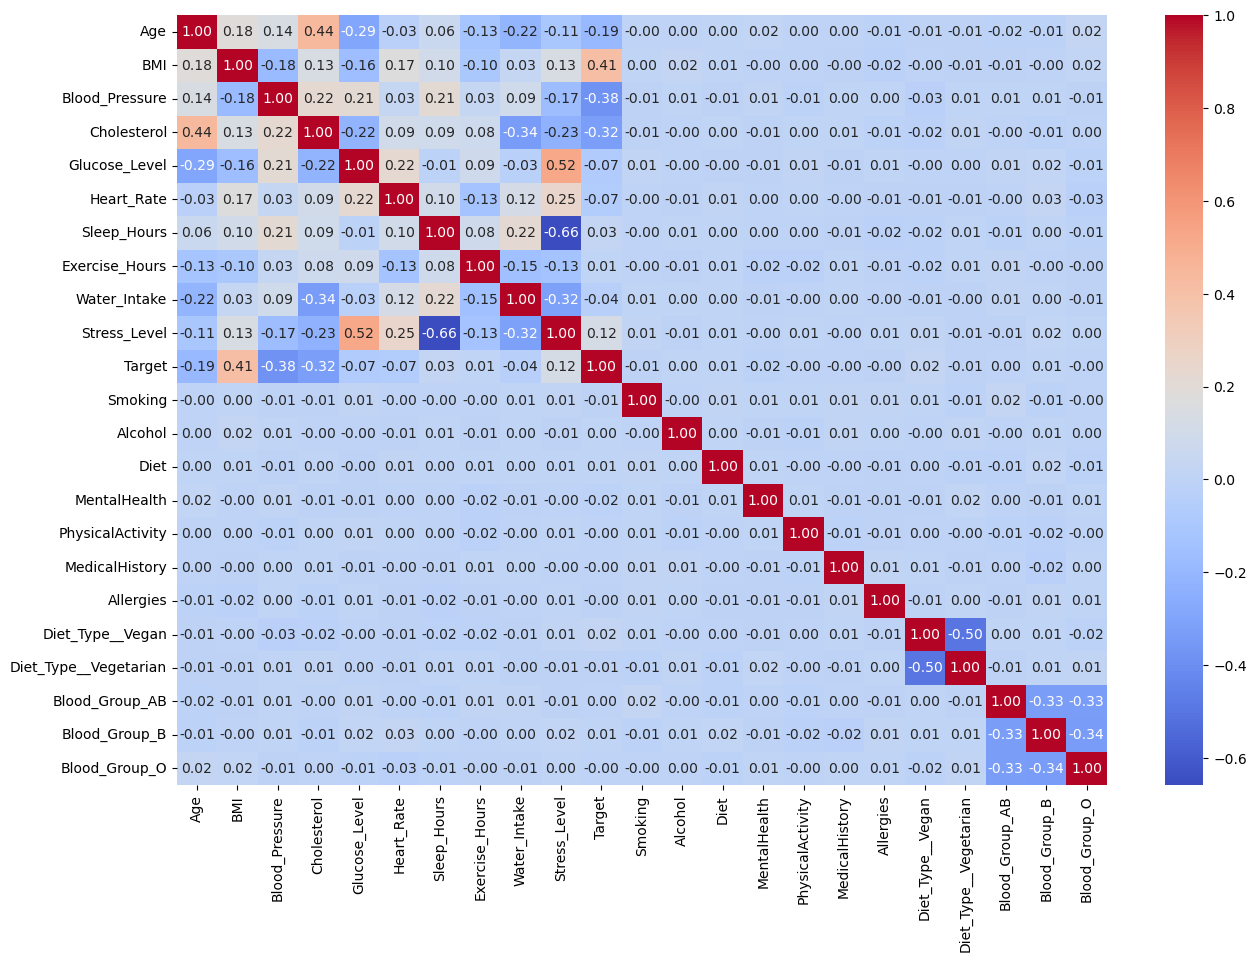

In [54]:

plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt="0.2f",
    cmap="coolwarm"
)

In [65]:
X = df.drop("Target",axis=1)
y= df["Target"]

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train , X_test , y_train , y_test = train_test_split(
    X,y , test_size=.30 , random_state=42 
)

In [67]:
scalar =StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)

X_test_scaled = scalar.transform(X_test)

In [68]:
from sklearn.linear_model import LogisticRegressionCV


Lr = LogisticRegressionCV(
    max_iter=2000,
    cv=7,
    
)

In [70]:
Lr.fit(X_train_scaled,y_train)
y_pred = Lr.predict(X_test_scaled)

from sklearn.metrics import accuracy_score ,classification_report

print("accuracy_score : " , accuracy_score(y_test,y_pred))
print("classification_report  :\n",classification_report(y_test,y_pred))

accuracy_score :  0.8184991273996509
classification_report  :
               precision    recall  f1-score   support

           0       0.81      0.80      0.81      1356
           1       0.83      0.83      0.83      1509

    accuracy                           0.82      2865
   macro avg       0.82      0.82      0.82      2865
weighted avg       0.82      0.82      0.82      2865



In [73]:
from sklearn.neighbors import KNeighborsClassifier

knn_c = KNeighborsClassifier(
    n_neighbors= 7, 

)

knn_c.fit(X_train_scaled, y_train)


y_pred = knn_c.predict(X_test_scaled)


print("accuracy_score : " , accuracy_score(y_test,y_pred))
print("classification_report  :\n",classification_report(y_test,y_pred))

accuracy_score :  0.874694589877836
classification_report  :
               precision    recall  f1-score   support

           0       0.87      0.87      0.87      1356
           1       0.88      0.88      0.88      1509

    accuracy                           0.87      2865
   macro avg       0.87      0.87      0.87      2865
weighted avg       0.87      0.87      0.87      2865



In [76]:
from sklearn.ensemble import RandomForestClassifier

rtf_c = RandomForestClassifier(
    n_estimators=1000,
    max_depth=7,
    oob_score=True,
    bootstrap=True,
    random_state=42
)

rtf_c.fit(X_train_scaled,y_train)

y_pred = rtf_c.predict(X_test_scaled)


print("accuracy_score : " , accuracy_score(y_test,y_pred))
print("classification_report  :\n",classification_report(y_test,y_pred))



accuracy_score :  0.9050610820244328
classification_report  :
               precision    recall  f1-score   support

           0       0.93      0.86      0.90      1356
           1       0.89      0.94      0.91      1509

    accuracy                           0.91      2865
   macro avg       0.91      0.90      0.90      2865
weighted avg       0.91      0.91      0.90      2865



In [78]:
from sklearn.ensemble import GradientBoostingClassifier

gB_C = GradientBoostingClassifier(
    n_estimators=1000,
    max_depth=5,
    random_state=42
)

gB_C.fit(X_train_scaled,y_train)

y_pred = gB_C.predict(X_test_scaled)

print("accuracy_score : " , accuracy_score(y_test,y_pred))
print("classification_report  :\n",classification_report(y_test,y_pred))

accuracy_score :  0.9504363001745201
classification_report  :
               precision    recall  f1-score   support

           0       0.95      0.95      0.95      1356
           1       0.95      0.95      0.95      1509

    accuracy                           0.95      2865
   macro avg       0.95      0.95      0.95      2865
weighted avg       0.95      0.95      0.95      2865



In [95]:
from sklearn.ensemble import VotingClassifier

vC = VotingClassifier(
    estimators=[
        ("lr", LogisticRegressionCV(max_iter=1000, cv=7, solver="liblinear")),
        ("knn_c", KNeighborsClassifier(n_neighbors=5)),
        ("rtf_c", RandomForestClassifier(n_estimators=200, random_state=42))
    ],
    voting="soft"
    
)

vC.fit(X_train_scaled,y_train)

,estimators,"[('lr', ...), ('knn_c', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,Cs,10
,fit_intercept,True
,cv,7
,dual,False
,penalty,'l2'


In [97]:
y_pred = vC.predict(X_test_scaled)


print("accuracy_score : " , accuracy_score(y_test,y_pred))
print("classification_report  :\n",classification_report(y_test,y_pred))

accuracy_score :  0.9102966841186736
classification_report  :
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1356
           1       0.91      0.93      0.92      1509

    accuracy                           0.91      2865
   macro avg       0.91      0.91      0.91      2865
weighted avg       0.91      0.91      0.91      2865

